<a href="https://colab.research.google.com/github/ClassNeuralNetwork/Regression-CaloricExpenditurePrediction/blob/main/caloricExpenditurePrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install shap

In [2]:
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import shap

In [3]:
path = kagglehub.dataset_download("fmendes/fmendesdat263xdemos")
print(os.listdir(path))

Using Colab cache for faster access to the 'fmendesdat263xdemos' dataset.
['exercise.csv', 'calories.csv']


##Preparar dados



In [4]:
df_exercise = pd.read_csv(os.path.join(path, "exercise.csv"))
df_calories = pd.read_csv(os.path.join(path, "calories.csv"))

df = pd.merge(df_exercise, df_calories, on="User_ID")
display(df.head())

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


In [5]:
df = pd.get_dummies(df, columns=['Gender'], drop_first=True)

X = df.drop(columns=['Calories', 'User_ID'])
y = df['Calories'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [6]:
feature_names = ['Idade', 'Altura', 'Peso', 'Duração', 'Batimentos', 'Temp. Corporal', 'Sexo (M=1)']

## Criando modelo


In [15]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=(X_train.shape[1],)), # 7 neuronios
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,625 (10.25 KB)

 Trainable params: 2,625 (10.25 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
model.compile(optimizer='adam', loss='mse')

history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2, verbose=0)

In [24]:
y_pred = model.predict(X_test)
y_pred = y_pred.reshape(y_pred.shape[0])

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'MSE: {mse:.2f}\nR2: {r2:.4f}\nMAE: {mae:.2f}\nRMSE: {rmse:.2f}')

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MSE: 0.20
R2: 0.9999
MAE: 0.35
RMSE: 0.45


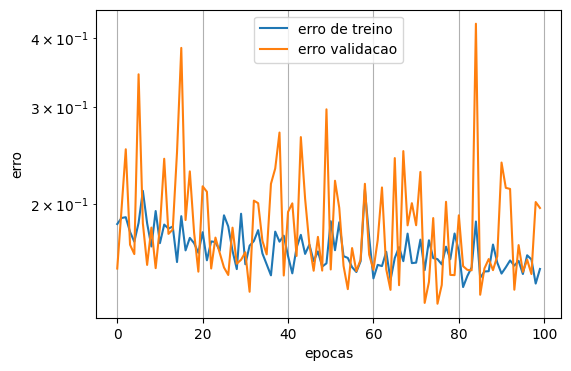

In [25]:
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='erro de treino')
plt.plot(history.history['val_loss'], label='erro validacao')
plt.xlabel('epocas')
plt.ylabel('erro')
plt.yscale('log')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
          #mlp-Nneuronios-Kepocas-V.keras
model.save('mlp-128-100-2.keras')

print("Modelo salvo com sucesso!")

Modelo salvo com sucesso!


# ia explicavel

In [ ]:
explainer = shap.KernelExplainer(model.predict, X_test[:1])
shap_values = explainer.shap_values(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


  0%|          | 0/3000 [00:00<?, ?it/s]

Streaming output truncated to the last 5000 lines.
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

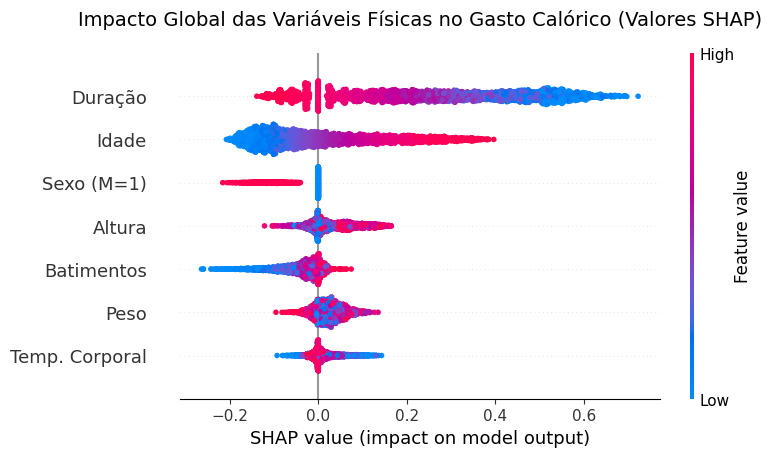

In [ ]:
if isinstance(shap_values, list):
  shap_values = shap_values[0]

if len(shap_values.shape) > 2:
  shap_values = np.squeeze(shap_values)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, feature_names=feature_names, show=False)
plt.title("Impacto Global das Variáveis Físicas no Gasto Calórico (Valores SHAP)", fontsize=14, pad=20)

plt.show()

## Informacoes do runtime

In [19]:
%%bash
# Informações detalhadas da CPU
echo "=== CPU ==="
lscpu | grep -E "Model name|Core\(s\) per socket|Thread\(s\) per core|CPU\(s\):"

# Memória RAM total e disponível
echo -e "\n=== MEMÓRIA RAM ==="
free -h

# Armazenamento em disco
echo -e "\n=== DISCO ==="
df -h / | awk '{print "Total: "$2" | Usado: "$3" | Disponível: "$4}'

# Sistema Operacional / Versão do Ubuntu
echo -e "\n=== SISTEMA OPERACIONAL ==="
lsb_release -d

=== CPU ===
CPU(s):                                  2
Model name:                              Intel(R) Xeon(R) CPU @ 2.00GHz
Thread(s) per core:                      2
Core(s) per socket:                      1
NUMA node0 CPU(s):                       0,1

=== MEMÓRIA RAM ===
               total        used        free      shared  buff/cache   available
Mem:            12Gi       2.3Gi       5.8Gi        16Mi       4.8Gi        10Gi
Swap:             0B          0B          0B

=== DISCO ===
Total: Size | Usado: Used | Disponível: Avail
Total: 236G | Usado: 48G | Disponível: 189G

=== SISTEMA OPERACIONAL ===
Description:	Ubuntu 24.04.1 LTS


In [20]:
import torch

if torch.cuda.is_available():
    print(f"GPU Ativa: {torch.cuda.get_device_name(0)}")
    print(f"Total de memória de vídeo (VRAM): {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("Nenhuma GPU foi detectada. Verifique se ativou o acelerador de hardware no menu.")


GPU Ativa: Tesla T4
Total de memória de vídeo (VRAM): 15.64 GB
